# Assignment 4

In [44]:
import pandas as pd
import numpy as np
import librosa
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from datasets import load_dataset

DATA = Path("data")
LJSPEECH = DATA / "LJSpeech-1.1"
PONY = DATA / "pony-speech"
IMG = Path("img")

if not IMG.exists():
  IMG.mkdir()

In [4]:
%%bash

./src/load_data.sh


Dataset already exists: ./data/LJSpeech-1.1


In [ ]:
ds = load_dataset("synthbot/pony-speech", cache_dir=PONY)

Resolving data files:   0%|          | 0/31 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/31 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/30 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['speaker', 'gender', 'source', 'start', 'end', 'style', 'noise', 'transcription', 'audio', 'duration'],
        num_rows: 64783
    })
})

## EDA and Metric Analysis

In [ ]:
data = pd.read_csv(LJSPEECH / "metadata.csv", sep="|", header=None, names=["file", "text", "normalized_text"])
data


,file,text,normalized_text
0,LJ001-0001,"Printing, in the only sense with which we are ...","Printing, in the only sense with which we are ..."
1,LJ001-0002,in being comparatively modern.,in being comparatively modern.
2,LJ001-0003,For although the Chinese took impressions from...,For although the Chinese took impressions from...
3,LJ001-0004,"produced the block books, which were the immed...","produced the block books, which were the immed..."
4,LJ001-0005,the invention of movable metal letters in the ...,the invention of movable metal letters in the ...
...,...,...,...
13095,LJ050-0274,made certain recommendations which it believes...,made certain recommendations which it believes...
13096,LJ050-0275,materially improve upon the procedures in effe...,materially improve upon the procedures in effe...
13097,LJ050-0276,"As has been pointed out, the Commission has no...","As has been pointed out, the Commission has no..."
13098,LJ050-0277,with the active cooperation of the responsible...,with the active cooperation of the responsible...


### Statistics

From the README:

| Metric | Value |
| --- | --- |
| Total Clips | 13,100 |
| Total Words | 225,715 |
| Total Characters | 1,308,674 |
| Total Duration | 23:55:17 |
| Mean Clip Duration | 6.57 sec |
| Min Clip Duration | 1.11 sec |
| Max Clip Duration | 10.10 sec |
| Mean Words per Clip | 17.23 |
| Distinct Words | 13,821 |

### Abbreviations

Some words are abbreviated in the transcript:

| Abbreviation | Expansion |
| --- | --- |
| Mr. | Mister |
| Mrs. | Misess (*) |
| Dr. | Doctor |
| No. | Number |
| St. | Saint |
| Co. | Company |
| Jr. | Junior |
| Maj. | Major |
| Gen. | General |
| Drs. | Doctors |
| Rev. | Reverend |
| Lt. | Lieutenant |
| Hon. | Honorable |
| Sgt. | Sergeant |
| Capt. | Captain |
| Esq. | Esquire |
| Ltd. | Limited |
| Col. | Colonel |
| Ft. | Fort |

* there's no standard expansion of "Mrs."

In [ ]:
SR = 22050

paths = []
for f in data["file"]:
  path = LJSPEECH / f"wavs/{f}.wav"
  paths.append(str(path))
  _, sr = librosa.load(path, sr=None)

  if SR is None:
    SR = sr
  elif SR != sr:
    print(f"File {f} has a different sample rate: {sr} != {SR}")

data['path'] = paths
SR

22050

In [14]:
data

,file,text,normalized_text,path
0,LJ001-0001,"Printing, in the only sense with which we are ...","Printing, in the only sense with which we are ...",data/LJSpeech-1.1/wavs/LJ001-0001.wav
1,LJ001-0002,in being comparatively modern.,in being comparatively modern.,data/LJSpeech-1.1/wavs/LJ001-0002.wav
2,LJ001-0003,For although the Chinese took impressions from...,For although the Chinese took impressions from...,data/LJSpeech-1.1/wavs/LJ001-0003.wav
3,LJ001-0004,"produced the block books, which were the immed...","produced the block books, which were the immed...",data/LJSpeech-1.1/wavs/LJ001-0004.wav
4,LJ001-0005,the invention of movable metal letters in the ...,the invention of movable metal letters in the ...,data/LJSpeech-1.1/wavs/LJ001-0005.wav
...,...,...,...,...
13095,LJ050-0274,made certain recommendations which it believes...,made certain recommendations which it believes...,data/LJSpeech-1.1/wavs/LJ050-0274.wav
13096,LJ050-0275,materially improve upon the procedures in effe...,materially improve upon the procedures in effe...,data/LJSpeech-1.1/wavs/LJ050-0275.wav
13097,LJ050-0276,"As has been pointed out, the Commission has no...","As has been pointed out, the Commission has no...",data/LJSpeech-1.1/wavs/LJ050-0276.wav
13098,LJ050-0277,with the active cooperation of the responsible...,with the active cooperation of the responsible...,data/LJSpeech-1.1/wavs/LJ050-0277.wav


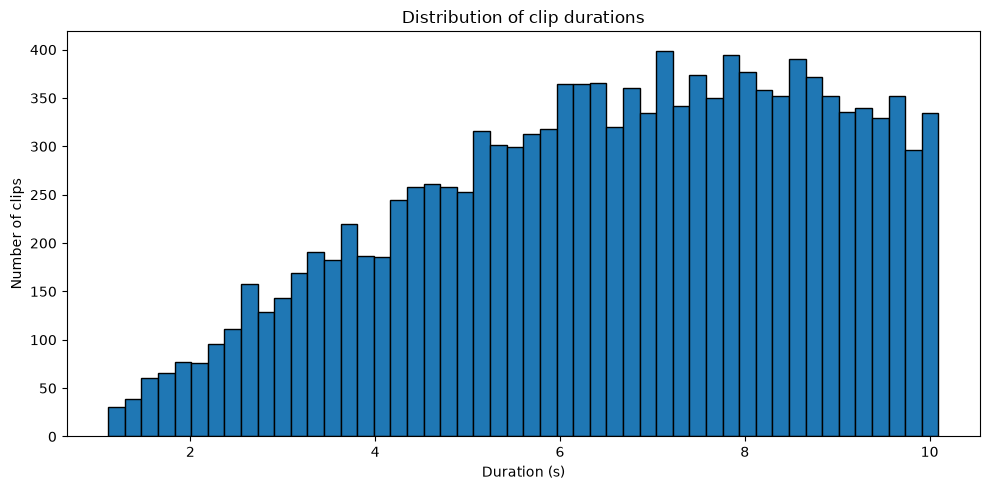

In [31]:
d = [librosa.get_duration(path=p) for p in data['path']]

fig = plt.figure(figsize=(10, 5))
plt.hist(d, bins=50, edgecolor='black')
plt.xlabel('Duration (s)')
plt.ylabel('Number of clips')
plt.title('Distribution of clip durations')
plt.tight_layout()
plt.show()
fig.savefig("img/clip_duration.png", dpi=300)

In [ ]:
train, val = train_test_split(data, train_size=0.9, random_state=42)

train.to_parquet(LJSPEECH / "train.parquet")
val.to_parquet(LJSPEECH / "val.parquet")